In [7]:
!pip install scipy
!pip install matplotlib



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ------- -------------------------------- 1.8/9.5 MB 14.7 MB/s eta 0:00:01
   ------------------------ --------------- 5.8/9.5 MB 17.0 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 17.2 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 16.4 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 34.0 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ------------- -------------------------- 2.4/7.2 MB 11.3 MB/s eta 0:00:01
   ------------------------------ --------- 5.5/7.2 MB 13.7 MB/s eta 0:00:01
   ------------------------------------ --- 6.6/7.2 MB 10.8 MB/s eta 0:00:


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from scipy.io import loadmat
mammal_mat = loadmat('mammal_data_small.mat')

In [4]:
# 1\. Print available data keys (filtering out MATLAB header info) data\
data_keys = [key for key in mammal_mat.keys() if not key.startswith('__')] 
print("Dataset Keys:", data_keys)

Dataset Keys: ['data_matrix', 'label_key']


In [6]:
import numpy as np
# 2. Inspect array shapes and data types
for key in data_keys: 
    data = mammal_mat[key] 
    if isinstance(data, np.ndarray): 
        print(f"Key: '{key}' | Shape: {data.shape} | Data Type: {data.dtype}") 
    else: print(f"Key: '{key}' | Type: {type(data)}")

Key: 'data_matrix' | Shape: (150, 88200) | Data Type: float64
Key: 'label_key' | Shape: (150,) | Data Type: <U28


In [8]:
import matplotlib.pyplot as plt 
from scipy.signal import spectrogram 


In [11]:
data_matrix= mammal_mat['data_matrix']
label_key= mammal_mat['label_key']

uniuqe_species= np.unique(label_key)
print("unique species lable: \n ", label_key[0])


unique species lable: 
  AtlanticSpottedDolphin      


In [12]:
print("\n label for clip #0: ", label_key[0])


 label for clip #0:  AtlanticSpottedDolphin      


In [13]:
first_audio_clip= data_matrix[0]

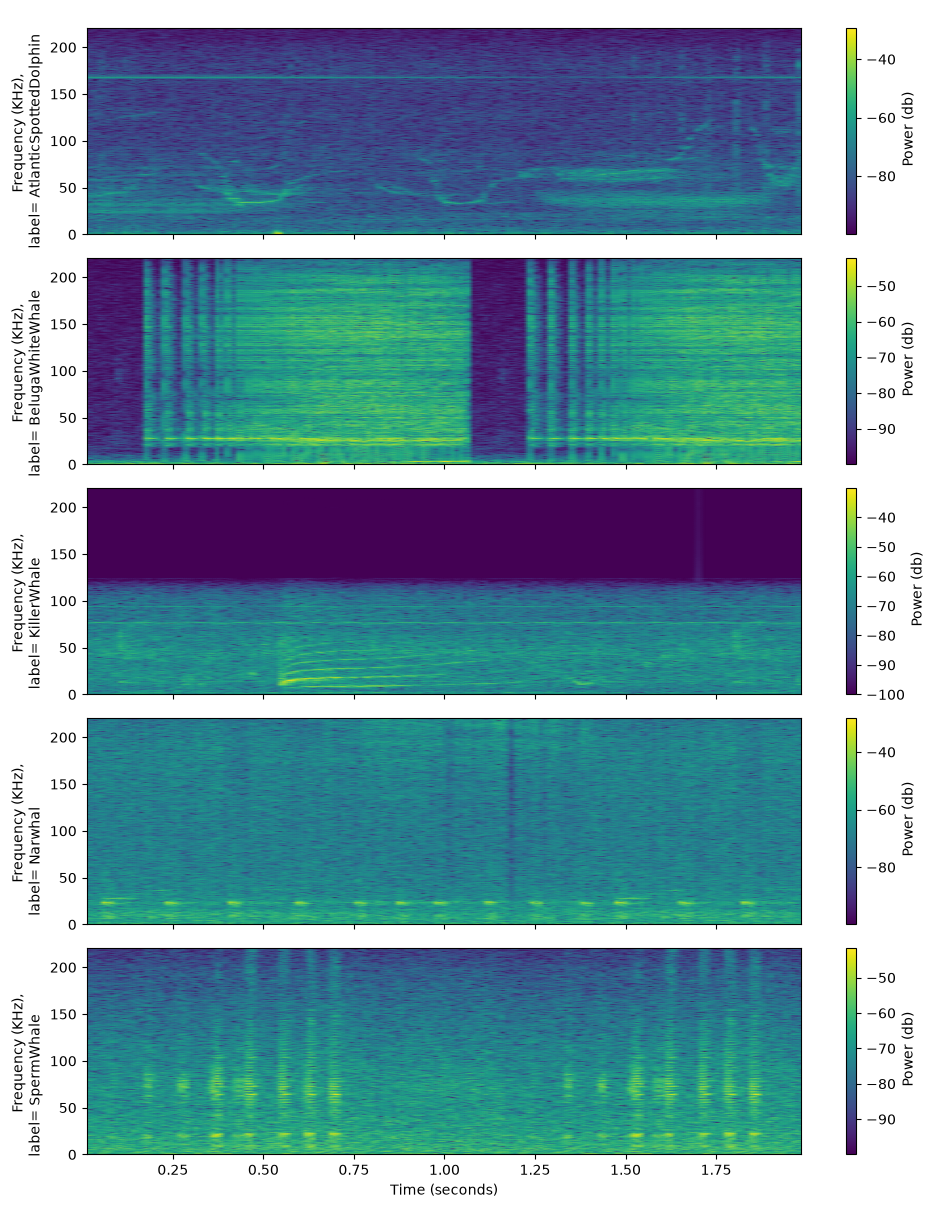

In [21]:
fs= 44100 # sampling rate: 44.1 KHz

uniuqe_species= np.unique(label_key)
fig, axes= plt.subplots(len(uniuqe_species), 1, figsize= (10, 12), sharex= True)

for i, species_name in enumerate(uniuqe_species):
    sample_indices= np.where(label_key == species_name)[0]
    first_sample_idx= sample_indices[0]
    signal= data_matrix[first_sample_idx]

    frequencies, time, Sxx= spectrogram(signal, fs=fs, nperseg= 1024, noverlap= 512)
    Sxx_db= 10 * np.log10(Sxx + 1e-10)
    im= axes[i].pcolormesh(time, frequencies / 100, Sxx_db, shading= 'gouraud', cmap= 'viridis')
    axes[i].set_ylabel(f'Frequency (KHz), \n label= {species_name}')
    fig.colorbar(im, ax= axes[i], label=' Power (db)')

axes[-1].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.show()


In [18]:
from IPython.display import Audio, display

for species in uniuqe_species:
    sample_idx= np.where(label_key == species)[0][0]
    signal= data_matrix[sample_idx]
    print(f" species: {species} (clip index: {sample_idx})")
    display(Audio(data= signal, rate= fs))
    print("-" * 50)

 species: AtlanticSpottedDolphin       (clip index: 0)


--------------------------------------------------
 species: BelugaWhiteWhale             (clip index: 30)


--------------------------------------------------
 species: KillerWhale                  (clip index: 60)


--------------------------------------------------
 species: Narwhal                      (clip index: 120)


--------------------------------------------------
 species: SpermWhale                   (clip index: 90)


--------------------------------------------------


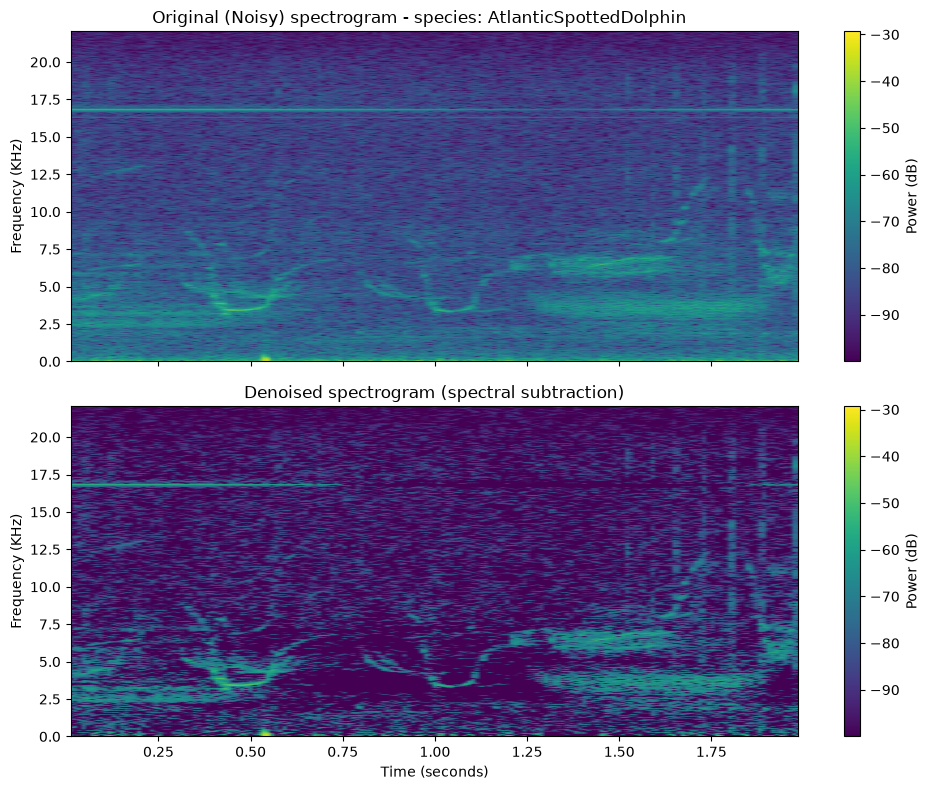

In [26]:
from scipy.signal import spectrogram, butter, filtfilt


sample_idx=0
noisy_signal= data_matrix[sample_idx]
species_name= label_key[sample_idx]

#compute noisy spectrogram

frequencies, times, Sxx_noisy= spectrogram(noisy_signal, fs=fs, nperseg= 1024, noverlap= 512)

#denoise via spectral subtraction

noise_profile= np.median(Sxx_noisy, axis= 1, keepdims= True)

#substract noisy profile with scaling factor (alpha)

alpha= 1.2

Sxx_denoised= np.maximum(Sxx_noisy - alpha * noise_profile, 1e-10)

#convert both power spectra to dB scale

Sxx_db_noisy= 10 * np.log10(Sxx_noisy + 1e-10)
Sxx_db_denoised= 10 * np.log10(Sxx_denoised)

#plot comparison

fig, axes= plt.subplots(2, 1, figsize= (10, 8), sharex= True)

#plot noisy spectrogram

im0= axes[0].pcolormesh(times, frequencies / 1000, Sxx_db_noisy, shading= 'gouraud', cmap= 'viridis')
axes[0].set_title(f'Original (Noisy) spectrogram - species: {species_name}')
axes[0].set_ylabel('Frequency (KHz)')
fig.colorbar(im0, ax=axes[0], label= 'Power (dB)')

#plot denoise spectrogram

im1= axes[1].pcolormesh(times, frequencies / 1000, Sxx_db_denoised, shading= 'gouraud', cmap= 'viridis')
axes[1].set_title(f'Denoised spectrogram (spectral subtraction)')
axes[1].set_ylabel('Frequency (KHz)')
axes[1].set_xlabel('Time (seconds)')
fig.colorbar(im0, ax=axes[1], label= 'Power (dB)')

plt.tight_layout()
plt.show()



In [28]:
from scipy.signal import stft, istft 
frquencies, times, Zxx= stft(noisy_signal, fs= fs, nperseg= 1024, noverlap= 512)
magnitude= np.abs(Zxx)
phase= np.angle(Zxx)

# spectral subtraction 
noise_profile= np.median(magnitude, axis= 1, keepdims=True)
alpha= 1.2

denoised_magnitude= np.maximum(magnitude - alpha * noise_profile, 0)

Zxx_denoised= denoised_magnitude * np.exp(1j * phase)
_, denoised_signal= istft(Zxx_denoised, fs=fs, nperseg= 1024, noverlap= 512)



print(f"Species: {species_name} (clip index #{sample_idx})")
print("\n Original noisy audio: ")
display(Audio(data= noisy_signal, rate= fs))

print(f"Denoised audio (spectral subtraction )")
display(Audio(data= denoised_signal, rate= fs))



Species: AtlanticSpottedDolphin       (clip index #0)

 Original noisy audio: 


Denoised audio (spectral subtraction )
